# Lab: Adversarial Attacks and Adversarial Training


------------------------------------------------------
*Pablo M. Olmos pamartin@ing.uc3m.es*

------------------------------------------------------



## A canonical example: adversarial perturbations

The following figure comes from *Goodfellow et al., 2015* and illustrates how an imperceptible perturbation can completely change a modelâ€™s prediction.

![Adversarial example: panda to gibbon](https://uvadlc-notebooks.readthedocs.io/en/latest/_images/adversarial_example.svg)

From left to right:

- **Original image**: correctly classified as *panda*
- **Adversarial noise**: visually imperceptible (amplified for display in the paper)
- **Adversarial image**: classified as *gibbon* with high confidence

This example highlights that adversarial attacks do not rely on semantic changes, but on exploiting vulnerabilities in the modelâ€™s decision boundaries.


## What is an adversarial example?

An **adversarial example** is a slightly modified input that causes a neural
network to make an incorrect prediction.

Given an input image $x$ and a classifier $f_\theta$, we search for a small
perturbation $\delta$ such that $f_\theta(x) \neq f_\theta(x + \delta)$
while keeping the perturbation imperceptibly small:

$\|\delta\|_\infty \le \varepsilon$

The adversarial image is defined as

$x_{\text{adv}} = \text{clip}(x + \delta)$

where the clipping operation ensures that pixel values remain in the valid
range (e.g. $[0,1]$).


## Threat model: White-box attacks

In this notebook we assume a **white-box attacker**, meaning:

- The model architecture is known
- The model parameters $\theta$ are known
- Gradients $\nabla_x \mathcal{L}(f_\theta(x), y)$ can be computed

This setting allows us to design efficient gradient-based attacks.


## Fast Gradient Sign Method (FGSM)

The **Fast Gradient Sign Method (FGSM)** is a single-step adversarial attack.

Given a loss function $\mathcal{L}$, the perturbation is computed as

$\delta = \varepsilon \cdot \text{sign}\left(\nabla_x \mathcal{L}(f_\theta(x), y)\right)$

The adversarial example is then

$x_{\text{adv}} = \text{clip}(x + \delta)$

Key properties:

- Very fast (one gradient computation)
- Often sufficient to fool standard CNNs
- Serves as the basis for stronger iterative attacks


## Intuition behind FGSM

The gradient $\nabla_x \mathcal{L}(f_\theta(x), y)$ indicates how each pixel
should change to **increase the loss**.

FGSM takes the **sign** of this gradient and pushes each pixel to its maximum
allowed change $\varepsilon$ in the direction that most increases the loss.

Even though the perturbation is small, it is coordinated across all pixels,
which makes it highly effective.


## Projected Gradient Descent (PGD)

**Projected Gradient Descent (PGD)** is an iterative version of FGSM.

Starting from the original image $x^{(0)} = x$, we repeat

$x^{(t+1)} = \Pi_{B_\varepsilon(x)}\left(x^{(t)} + \alpha \cdot \text{sign}\left(\nabla_x \mathcal{L}(f_\theta(x^{(t)}), y)\right)\right)$

where:

- $\alpha$ is the step size
- $\Pi_{B_\varepsilon(x)}$ projects back onto the $\ell_\infty$ ball of radius
  $\varepsilon$ around the original image

PGD is considered a **strong first-order adversary** and is widely used for
robustness evaluation.


### How projection works (intuitively)

For each pixel independently:

- If it lies within the interval $[x_i - \varepsilon,\; x_i + \varepsilon]$, it is left unchanged.
- If it is larger than $x_i + \varepsilon$, it is clamped down to $x_i + \varepsilon$.
- If it is smaller than $x_i - \varepsilon$, it is clamped up to $x_i - \varepsilon$.

As a result, the projection step is simply an element-wise clipping operation that keeps the adversarial example within an $\ell_\infty$ distance $\varepsilon$ of the original image.


## Targeted vs untargeted attacks

### Untargeted attack

The goal is simply to cause **any misclassification**:

$\max_\delta \; \mathcal{L}(f_\theta(x + \delta), y)$

### Targeted attack

The goal is to force the model to predict a **specific target class**
$y_{\text{target}}$:

$\min_\delta \; \mathcal{L}(f_\theta(x + \delta), y_{\text{target}})$

Targeted attacks are typically harder and require stronger perturbations or
more iterations.


## Accuracy vs perturbation strength

A common way to evaluate adversarial robustness is to measure test accuracy
as a function of $\varepsilon$:

- $\varepsilon = 0$: clean accuracy
- Increasing $\varepsilon$: stronger attacks
- Rapid accuracy drop indicates lack of robustness

This evaluation helps visualize how fragile standard CNNs are to adversarial
perturbations.


## Key takeaways

- Adversarial examples exploit the **local linearity** of neural networks
- FGSM is fast and simple but already very effective
- PGD is stronger and often considered the "gold standard" attack
- Standard CNNs trained normally are **not robust** to adversarial noise

Adversarial robustness is an important consideration when deploying deep
learning models in safety-critical applications.


## Setup (GPU)

This notebook will use **one GPU** if available. We set `CUDA_VISIBLE_DEVICES=0` and use `cuda:0`.


In [5]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Use only one GPU if one is available.
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

def set_seed(seed=0):
    """
    High-level overview:
    Set the random seed so results are more consistent across runs.
    """
    # Seed Python's random module.
    random.seed(seed)
    # Seed NumPy.
    np.random.seed(seed)
    # Seed PyTorch on CPU.
    torch.manual_seed(seed)
    # Seed PyTorch on GPU.
    torch.cuda.manual_seed_all(seed)

# Set the seed before training.
set_seed(0)

# Use GPU if possible, otherwise use CPU.
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.cuda.set_device(0)
    torch.backends.cudnn.benchmark = True
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")


Using GPU: NVIDIA GeForce RTX 3050 4GB Laptop GPU


In [6]:
batch_size = 128

# Keep images in the [0, 1] range.
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load MNIST.
train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# DataLoader settings.
pin_memory = (device.type == "cuda")
num_workers = 4 if (os.name != "nt") else 0
num_workers = min(num_workers, os.cpu_count() or 2)

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=(num_workers > 0),
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=(num_workers > 0),
)

# Check one batch shape.
x0, y0 = next(iter(train_loader))
print("Batch:", x0.shape, y0.shape)


100.0%
100.0%
100.0%
100.0%


Batch: torch.Size([128, 1, 28, 28]) torch.Size([128])


# Part I: Standard Training Baseline

This section begins the **standard training** workflow for the small MNIST CNN.

We will:

- define the baseline model
- train it with cross-entropy on clean data
- evaluate clean and robust accuracy
- measure calibration with NLL, ECE, and reliability diagrams


In [7]:
class SmallCNN(nn.Module):
    def __init__(self):
        """
        High-level overview:
        Build a small CNN for MNIST.
        """
        super().__init__()
        # First convolution layer.
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        # Second convolution layer.
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        # Fully connected layers for classification.
        self.fc1   = nn.Linear(64 * 7 * 7, 128)
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        """
        High-level overview:
        Run the image through the network and return class scores.
        """
        # Conv -> ReLU -> pool.
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        # Conv -> ReLU -> pool again.
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        # Flatten before the linear layers.
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# Create the baseline model.
model = SmallCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [8]:
def train_one_epoch(model, loader, optimizer):
    """
    High-level overview:
    Train the model for one full pass over the training data.
    """
    model.train()
    total_loss, total = 0.0, 0

    for x, y in loader:
        # Move data to the right device.
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        # Clear old gradients.
        optimizer.zero_grad(set_to_none=True)
        # Get predictions.
        logits = model(x)
        # Compute cross-entropy loss.
        loss = F.cross_entropy(logits, y)
        # Backpropagation.
        loss.backward()
        # Update weights.
        optimizer.step()

        # Keep track of average loss.
        total_loss += loss.item() * x.size(0)
        total += x.size(0)

    return total_loss / total

@torch.no_grad()
def eval_accuracy(model, loader):
    """
    High-level overview:
    Measure accuracy on a dataset.
    """
    model.eval()
    correct, total = 0, 0

    for x, y in loader:
        # Move data to the right device.
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        # Predicted class is the largest logit.
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item()
        total += x.size(0)

    return correct / total

# Train the standard model for a few epochs.
standard_epochs = 3
for epoch in range(standard_epochs):
    loss = train_one_epoch(model, train_loader, optimizer)
    acc = eval_accuracy(model, test_loader)
    print(f"[standard-train] epoch={epoch+1} loss={loss:.4f} test_acc={acc*100:.2f}%")


[standard-train] epoch=1 loss=0.2223 test_acc=97.74%
[standard-train] epoch=2 loss=0.0584 test_acc=98.14%
[standard-train] epoch=3 loss=0.0410 test_acc=98.84%


In [9]:
def clamp01(x):
    """
    High-level overview:
    Keep image values between 0 and 1.
    """
    return torch.clamp(x, 0.0, 1.0)

@torch.no_grad()
def predict(model, x):
    """
    High-level overview:
    Return predicted classes for a batch.
    """
    model.eval()
    logits = model(x)
    return logits.argmax(dim=1)

def show_batch(images, labels=None, preds=None, n=8, title=None):
    """
    High-level overview:
    Show a few images, and optionally their true labels and predictions.
    """
    # Move images to CPU for plotting.
    images = images.detach().cpu()
    n = min(n, images.size(0))
    fig, axes = plt.subplots(1, n, figsize=(1.8 * n, 2.0))
    if n == 1:
        axes = [axes]

    for i in range(n):
        # MNIST images are grayscale.
        axes[i].imshow(images[i, 0], cmap="gray", vmin=0, vmax=1)
        axes[i].axis("off")
        title_lines = []
        if labels is not None:
            title_lines.append(f"y={int(labels[i])}")
        if preds is not None:
            title_lines.append(f"p={int(preds[i])}")
        axes[i].set_title("\n".join(title_lines), fontsize=10)

    if title:
        fig.suptitle(title)
    plt.show()

def l_inf_norm(x_adv, x):
    """
    High-level overview:
    Measure the largest pixel change in each image.
    """
    return (x_adv - x).abs().view(x.size(0), -1).max(dim=1).values


In [10]:
def fgsm_attack(model, x, y, eps, targeted=False, y_target=None):
    """
    High-level overview:
    Create adversarial images using one gradient step.
    """
    # Use evaluation mode while building the attack.
    model.eval()
    # Copy the input and allow gradients with respect to pixels.
    x_adv = x.clone().detach().requires_grad_(True)

    # Forward pass.
    logits = model(x_adv)

    if targeted:
        assert y_target is not None, "Provide y_target for targeted FGSM."
        # Move toward the target class.
        loss = F.cross_entropy(logits, y_target)
        grad_sign = torch.autograd.grad(loss, x_adv)[0].sign()
        x_adv = x_adv - eps * grad_sign
    else:
        # Move away from the true class.
        loss = F.cross_entropy(logits, y)
        grad_sign = torch.autograd.grad(loss, x_adv)[0].sign()
        x_adv = x_adv + eps * grad_sign

    # Keep valid image values.
    x_adv = clamp01(x_adv.detach())
    return x_adv


## Part I.A: Visual Attack Examples

Before running full-dataset evaluation, these cells show what FGSM and PGD perturbations look like on a sample batch.


In [11]:
def pgd_attack(model, x, y, eps, alpha, steps, random_start=True,
               targeted=False, y_target=None):
    """
    High-level overview:
    Create adversarial images using many small gradient steps.
    """
    model.eval()

    # Save the original image so we can stay close to it.
    x_orig = x.detach()
    if random_start:
        # Start from a random point inside the epsilon ball.
        x_adv = x_orig + (2 * torch.rand_like(x_orig) - 1.0) * eps
        x_adv = clamp01(x_adv)
    else:
        x_adv = x_orig.clone()

    for _ in range(steps):
        # Turn gradients back on for the current attack step.
        x_adv = x_adv.clone().detach().requires_grad_(True)
        logits = model(x_adv)

        if targeted:
            assert y_target is not None, "Provide y_target for targeted PGD."
            loss = F.cross_entropy(logits, y_target)
            grad = torch.autograd.grad(loss, x_adv)[0]
            # Move toward the target class.
            x_adv = x_adv - alpha * grad.sign()
        else:
            loss = F.cross_entropy(logits, y)
            grad = torch.autograd.grad(loss, x_adv)[0]
            # Move away from the true class.
            x_adv = x_adv + alpha * grad.sign()

        # Keep the perturbation inside the allowed epsilon range.
        delta = torch.clamp(x_adv - x_orig, min=-eps, max=eps)
        x_adv = clamp01(x_orig + delta)

    return x_adv.detach()


In [12]:
def pgd_attack(model, x, y, eps, alpha, steps, random_start=True,
               targeted=False, y_target=None):
    """
    High-level overview:
    Run projected gradient descent inside an L-infinity ball around the clean
    image, giving a much stronger robustness evaluation than single-step FGSM.
    """
    model.eval()

    # Keep a detached copy of the clean image because projection is always
    # defined relative to the original sample, not the latest iterate.
    x_orig = x.detach()
    if random_start:
        # Random starts make PGD harder to overfit and usually strengthen it.
        x_adv = x_orig + (2 * torch.rand_like(x_orig) - 1.0) * eps
        x_adv = clamp01(x_adv)
    else:
        x_adv = x_orig.clone()

    for _ in range(steps):
        # Re-enable gradients at every iteration on the latest adversarial point.
        x_adv = x_adv.clone().detach().requires_grad_(True)
        logits = model(x_adv)

        if targeted:
            assert y_target is not None, "Provide y_target for targeted PGD."
            loss = F.cross_entropy(logits, y_target)
            grad = torch.autograd.grad(loss, x_adv)[0]
            # Targeted PGD descends toward the chosen target class.
            x_adv = x_adv - alpha * grad.sign()
        else:
            loss = F.cross_entropy(logits, y)
            grad = torch.autograd.grad(loss, x_adv)[0]
            # Untargeted PGD ascends the true-label loss.
            x_adv = x_adv + alpha * grad.sign()

        # Project the perturbation back into the L-infinity epsilon-ball.
        delta = torch.clamp(x_adv - x_orig, min=-eps, max=eps)
        x_adv = clamp01(x_orig + delta)

    return x_adv.detach()


In [13]:
@torch.no_grad()
def eval_clean(model, loader):
    """
    High-level overview:
    Measure accuracy on clean test images.
    """
    model.eval()
    correct, total = 0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item()
        total += x.size(0)

    return correct / total

def eval_under_attack(model, loader, attack_fn):
    """
    High-level overview:
    Measure accuracy after attacking each batch.
    """
    model.eval()
    correct, total = 0, 0

    for x, y in loader:
        # Do not use no_grad here because the attack needs gradients.
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        x_adv = attack_fn(x, y)
        with torch.no_grad():
            pred = model(x_adv).argmax(1)
        correct += (pred == y).sum().item()
        total += x.size(0)

    return correct / total


In [14]:
@torch.no_grad()
def eval_clean(model, loader):
    """
    High-level overview:
    Compute clean test accuracy, which serves as the standard generalization
    baseline before comparing adversarial robustness.
    """
    model.eval()
    correct, total = 0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item()
        total += x.size(0)

    return correct / total

def eval_under_attack(model, loader, attack_fn):
    """
    High-level overview:
    Measure robust accuracy by attacking each batch first and then checking how
    often the model still predicts the true class.
    """
    model.eval()
    correct, total = 0, 0

    for x, y in loader:
        # Robust evaluation needs gradients inside attack_fn, so do not wrap the
        # full loop in torch.no_grad().
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        x_adv = attack_fn(x, y)
        with torch.no_grad():
            pred = model(x_adv).argmax(1)
        correct += (pred == y).sum().item()
        total += x.size(0)

    return correct / total


In [15]:
eps_list = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25]

clean_acc = eval_clean(model, test_loader)
print("Clean accuracy:", clean_acc)

fgsm_accs = []
pgd_accs  = []

for eps in eps_list:
    if eps == 0.0:
        fgsm_accs.append(clean_acc)
        pgd_accs.append(clean_acc)
        continue

    fgsm_acc = eval_under_attack(
        model, test_loader,
        attack_fn=lambda x, y, eps=eps: fgsm_attack(model, x, y, eps=eps)
    )
    pgd_acc = eval_under_attack(
        model, test_loader,
        attack_fn=lambda x, y, eps=eps: pgd_attack(model, x, y, eps=eps, alpha=eps/10, steps=20)
    )
    fgsm_accs.append(fgsm_acc)
    pgd_accs.append(pgd_acc)
    print(f"eps={eps:.2f}  FGSM={fgsm_acc*100:.2f}%  PGD={pgd_acc*100:.2f}%")


Clean accuracy: 0.9884
eps=0.05  FGSM=95.35%  PGD=94.51%
eps=0.10  FGSM=86.90%  PGD=77.73%
eps=0.15  FGSM=68.48%  PGD=29.63%
eps=0.20  FGSM=42.14%  PGD=1.58%
eps=0.25  FGSM=20.37%  PGD=0.00%


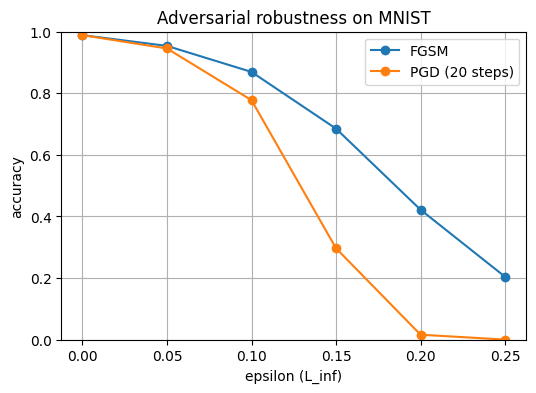

In [16]:
plt.figure(figsize=(6,4))
plt.plot(eps_list, fgsm_accs, marker="o", label="FGSM")
plt.plot(eps_list, pgd_accs,  marker="o", label="PGD (20 steps)")
plt.xlabel("epsilon (L_inf)")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.grid(True)
plt.legend()
plt.title("Adversarial robustness on MNIST")
plt.show()


## Part I.B: Standard Model Robustness Evaluation

This subsection measures how the clean-trained model performs on the test set under clean inputs, FGSM, and PGD attacks across different perturbation strengths.


## Comparison of attacks: accuracy vs $\varepsilon$

We compare test accuracy under different **white-box** adversarial attacks as a function of the perturbation budget $\varepsilon$ (using an $\ell_\infty$ constraint).

For each $\varepsilon$ we generate adversarial examples $x_{\text{adv}}$ and report:

- **Clean accuracy** (no attack)
- **FGSM** accuracy (1-step)
- **PGD** accuracy for different numbers of steps (stronger attacks)

Typically, as $\varepsilon$ increases and as the number of PGD steps increases, accuracy decreases.

attack,Clean,FGSM,PGD-10,PGD-40
epsilon,,,,
0.000000,0.988,nan,nan,nan
0.050000,0.988,0.954,0.945,0.945
0.100000,0.988,0.869,0.782,0.770
0.150000,0.988,0.685,0.313,0.269
0.200000,0.988,0.421,0.018,0.009
0.250000,0.988,0.204,0.000,0.000


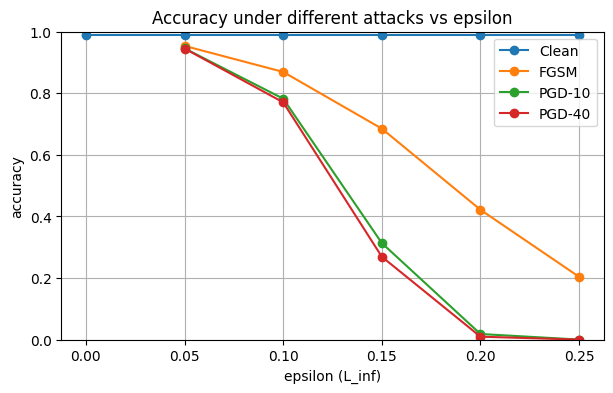

In [17]:
import pandas as pd

def attack_suite(model, eps, pgd_steps_list=(10, 40)):
    """
    High-level overview:
    Build a set of attacks to test for one epsilon value.
    """
    suite = {}
    # Include clean accuracy too.
    suite["Clean"] = lambda x, y: x
    if eps > 0:
        suite[f"FGSM (eps={eps:.2f})"] = lambda x, y: fgsm_attack(model, x, y, eps=eps)
        for steps in pgd_steps_list:
            # Simple step-size choice for PGD.
            alpha = eps / 4 if eps > 0 else 0.0
            suite[f"PGD-{steps} (eps={eps:.2f})"] = lambda x, y, a=alpha, s=steps: pgd_attack(
                model, x, y, eps=eps, alpha=a, steps=s, random_start=True
            )
    return suite

def eval_attack_accuracy(model, loader, attack_fn):
    """
    High-level overview:
    Measure accuracy for one chosen attack.
    """
    model.eval()
    correct, total = 0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        x_adv = attack_fn(x, y)
        with torch.no_grad():
            pred = model(x_adv).argmax(1)
        correct += (pred == y).sum().item()
        total += x.size(0)

    return correct / total

def sweep_attacks(model, loader, eps_list, pgd_steps_list=(10, 40), max_batches=None):
    """
    High-level overview:
    Test several attacks across several epsilon values.
    """
    rows = []

    for eps in eps_list:
        suite = attack_suite(model, eps, pgd_steps_list=pgd_steps_list)
        for name, fn in suite.items():
            # Optionally use only part of the test set.
            if max_batches is None:
                acc = eval_attack_accuracy(model, loader, fn)
            else:
                model.eval()
                correct, total = 0, 0
                for bi, (x, y) in enumerate(loader):
                    if bi >= max_batches:
                        break
                    x = x.to(device, non_blocking=True)
                    y = y.to(device, non_blocking=True)
                    x_adv = fn(x, y)
                    with torch.no_grad():
                        pred = model(x_adv).argmax(1)
                    correct += (pred == y).sum().item()
                    total += x.size(0)
                acc = correct / total

            rows.append({
                "epsilon": float(eps),
                "attack": name.split(" (eps=")[0],
                "accuracy": acc,
            })

    df = pd.DataFrame(rows)
    return df

# Run the attack sweep.
eps_list = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25]
df_attacks = sweep_attacks(model, test_loader, eps_list, pgd_steps_list=(10, 40), max_batches=None)

# Show results as a table.
table = df_attacks.pivot_table(index="epsilon", columns="attack", values="accuracy")
display(table.style.format("{:.3f}"))

# Plot the results.
plt.figure(figsize=(7, 4))
for col in table.columns:
    plt.plot(table.index, table[col], marker="o", label=col)
plt.xlabel("epsilon (L_inf)")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.grid(True)
plt.legend()
plt.title("Accuracy under different attacks vs epsilon")
plt.show()


## Part I.C: Standard Model Calibration Evaluation

This subsection studies whether the clean-trained model is well calibrated on clean and adversarial examples using NLL, ECE, and reliability diagrams.


## Standard training: robustness and calibration

For the project, the clean-trained MNIST CNN should be evaluated not only on
clean and adversarial accuracy, but also on **probabilistic calibration**.

In the next cells we compute:

- Clean accuracy
- FGSM robust accuracy
- PGD robust accuracy
- Negative Log-Likelihood (NLL)
- Expected Calibration Error (ECE)
- Reliability diagrams for clean, FGSM, and PGD predictions

This gives us a first view of how predictive confidence changes once the model
is exposed to stronger attacks.


In [18]:
def collect_logits_and_labels(model, loader, attack_fn=None, max_batches=None):
    """
    High-level overview:
    Collect model outputs and labels for later metric calculations.
    """
    model.eval()
    logits_list = []
    labels_list = []

    for batch_idx, (x, y) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        # Attack the batch if an attack function is given.
        if attack_fn is not None:
            x_eval = attack_fn(x, y)
        else:
            x_eval = x

        with torch.no_grad():
            logits = model(x_eval)

        # Move outputs to CPU for metric code.
        logits_list.append(logits.cpu())
        labels_list.append(y.cpu())

    return torch.cat(logits_list, dim=0), torch.cat(labels_list, dim=0)

def compute_nll(logits, labels):
    """
    High-level overview:
    Compute negative log-likelihood.
    """
    return F.cross_entropy(logits, labels).item()

def compute_ece(logits, labels, n_bins=15):
    """
    High-level overview:
    Measure how close confidence is to real accuracy.
    """
    probs = torch.softmax(logits, dim=1)
    confidences, predictions = probs.max(dim=1)
    accuracies = predictions.eq(labels)

    # Split confidence values into bins.
    bin_edges = torch.linspace(0.0, 1.0, steps=n_bins + 1)
    ece = torch.zeros(1, dtype=torch.float32)

    for bin_idx in range(n_bins):
        # Put each prediction into the right bin.
        lower = bin_edges[bin_idx]
        upper = bin_edges[bin_idx + 1]
        if bin_idx == n_bins - 1:
            in_bin = (confidences >= lower) & (confidences <= upper)
        else:
            in_bin = (confidences >= lower) & (confidences < upper)

        prop_in_bin = in_bin.float().mean()
        if prop_in_bin.item() > 0:
            accuracy_in_bin = accuracies[in_bin].float().mean()
            confidence_in_bin = confidences[in_bin].mean()
            ece += torch.abs(confidence_in_bin - accuracy_in_bin) * prop_in_bin

    return ece.item()

def reliability_diagram_from_logits(logits, labels, n_bins=15, ax=None, title="Reliability diagram"):
    """
    High-level overview:
    Draw a reliability diagram from logits and labels.
    """
    probs = torch.softmax(logits, dim=1)
    confidences, predictions = probs.max(dim=1)
    accuracies = predictions.eq(labels)
    bin_edges = torch.linspace(0.0, 1.0, steps=n_bins + 1)

    bin_centers = []
    bin_accuracies = []
    bin_confidences = []

    for bin_idx in range(n_bins):
        lower = bin_edges[bin_idx]
        upper = bin_edges[bin_idx + 1]
        if bin_idx == n_bins - 1:
            in_bin = (confidences >= lower) & (confidences <= upper)
        else:
            in_bin = (confidences >= lower) & (confidences < upper)

        if in_bin.any():
            bin_centers.append(((lower + upper) / 2).item())
            bin_accuracies.append(accuracies[in_bin].float().mean().item())
            bin_confidences.append(confidences[in_bin].mean().item())

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))

    # The dashed line is perfect calibration.
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
    ax.bar(
        bin_centers,
        bin_accuracies,
        width=1.0 / n_bins,
        alpha=0.6,
        edgecolor="black",
        label="Empirical accuracy",
    )
    ax.plot(bin_centers, bin_confidences, marker="o", color="tab:red", label="Mean confidence")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    return ax

def evaluate_model_metrics(model, loader, attack_name, attack_fn=None, n_bins=15, max_batches=None):
    """
    High-level overview:
    Compute accuracy, NLL, and ECE for one setting.
    """
    logits, labels = collect_logits_and_labels(
        model,
        loader,
        attack_fn=attack_fn,
        max_batches=max_batches,
    )

    probs = torch.softmax(logits, dim=1)
    predictions = probs.argmax(dim=1)

    return {
        "setting": attack_name,
        "accuracy": predictions.eq(labels).float().mean().item(),
        "nll": compute_nll(logits, labels),
        "ece": compute_ece(logits, labels, n_bins=n_bins),
        "logits": logits,
        "labels": labels,
    }

def summarize_standard_model(model, loader, fgsm_eps=0.15, pgd_eps=0.15, pgd_alpha=0.01, pgd_steps=20, n_bins=15):
    """
    High-level overview:
    Run clean, FGSM, and PGD evaluation for one model.
    """
    results = []

    # Clean evaluation.
    results.append(evaluate_model_metrics(model, loader, attack_name="Clean", attack_fn=None, n_bins=n_bins))
    # FGSM evaluation.
    results.append(
        evaluate_model_metrics(
            model,
            loader,
            attack_name=f"FGSM (eps={fgsm_eps:.2f})",
            attack_fn=lambda x, y: fgsm_attack(model, x, y, eps=fgsm_eps),
            n_bins=n_bins,
        )
    )
    # PGD evaluation.
    results.append(
        evaluate_model_metrics(
            model,
            loader,
            attack_name=f"PGD (eps={pgd_eps:.2f}, steps={pgd_steps})",
            attack_fn=lambda x, y: pgd_attack(model, x, y, eps=pgd_eps, alpha=pgd_alpha, steps=pgd_steps, random_start=True),
            n_bins=n_bins,
        )
    )

    summary_df = pd.DataFrame([
        {
            "setting": item["setting"],
            "accuracy": item["accuracy"],
            "nll": item["nll"],
            "ece": item["ece"],
        }
        for item in results
    ])

    return summary_df, results


Standard training evaluation (MNIST small CNN)


,setting,accuracy,nll,ece
0,Clean,0.9884,0.0348,0.0023
1,FGSM (eps=0.15),0.6848,0.9958,0.1550
2,"PGD (eps=0.15, steps=20)",0.2977,2.6129,0.5432


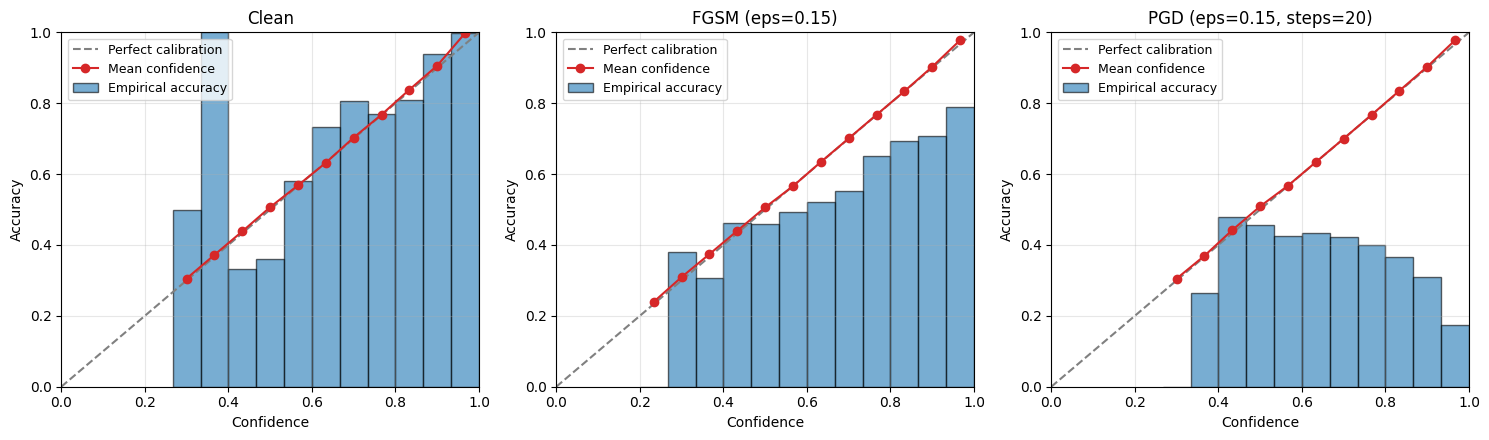

In [19]:
# Use a shared epsilon so the clean, FGSM, and PGD comparisons are easy to read.
standard_eval_eps = 0.15
standard_eval_pgd_steps = 20
standard_eval_pgd_alpha = standard_eval_eps / 10

standard_summary_df, standard_metric_cache = summarize_standard_model(
    model,
    test_loader,
    fgsm_eps=standard_eval_eps,
    pgd_eps=standard_eval_eps,
    pgd_alpha=standard_eval_pgd_alpha,
    pgd_steps=standard_eval_pgd_steps,
    n_bins=15,
)

print("Standard training evaluation (MNIST small CNN)")
display(standard_summary_df.style.format({
    "accuracy": "{:.4f}",
    "nll": "{:.4f}",
    "ece": "{:.4f}",
}))

# Plot one reliability diagram per evaluation condition.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, item in zip(axes, standard_metric_cache):
    reliability_diagram_from_logits(
        item["logits"],
        item["labels"],
        n_bins=15,
        ax=ax,
        title=item["setting"],
    )

plt.tight_layout()
plt.show()


# Part II: FGSM Adversarial Training

This section switches from standard training to **FGSM-based adversarial training** and then compares the robust behavior of the adversarially trained model against the clean baseline.


## Adversarial training (idea)

A common defense is **adversarial training**: during training, we mix clean inputs $x$ with adversarial inputs $x_{\text{adv}}$ crafted against the *current* model.

A standard formulation (Madry-style) is:

$\min_\theta \; \mathbb{E}_{(x,y)}\left[ \max_{\|\delta\|_\infty \le \varepsilon} \mathcal{L}(f_\theta(x+\delta), y) \right]$

Interpretation:

- The **inner maximization** finds a worst-case perturbation within an $\ell_\infty$ ball (a strong attacker).
- The **outer minimization** updates the model parameters $\theta$ to reduce the loss on those worst-case examples.

In practice we approximate the inner maximization with FGSM (fast, 1-step) or PGD (stronger, multi-step).


## Simple adversarial training with FGSM

We will implement a simple version of adversarial training:

1) Take a batch $(x, y)$  
2) Create adversarial examples with FGSM: $x_{\text{adv}} = \text{clip}(x + \varepsilon \cdot \text{sign}(\nabla_x \mathcal{L}(f_\theta(x), y)))$  
3) Train on a mixture of clean and adversarial examples.

We will use a mixing coefficient $\lambda \in [0,1]$:

$\mathcal{L}_{\text{mix}} = (1-\lambda)\,\mathcal{L}(f_\theta(x), y) + \lambda\,\mathcal{L}(f_\theta(x_{\text{adv}}), y)$

Typical observations:

- Clean accuracy may drop slightly
- Robust accuracy (under attack) improves substantially


In [20]:
def train_one_epoch_adv_fgsm(model, loader, optimizer, eps, lam=0.5):
    """
    High-level overview:
    Train for one epoch using both clean and FGSM-adversarial images.
    """
    model.train()
    total_loss, total = 0.0, 0

    for x, y in loader:
        # Move the batch to the device.
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        # Create FGSM adversarial examples.
        x_adv = fgsm_attack(model, x, y, eps=eps, targeted=False)

        # Compute clean and adversarial losses.
        optimizer.zero_grad(set_to_none=True)
        logits_clean = model(x)
        logits_adv = model(x_adv)

        loss_clean = F.cross_entropy(logits_clean, y)
        loss_adv = F.cross_entropy(logits_adv, y)

        # Mix the two losses.
        loss = (1 - lam) * loss_clean + lam * loss_adv
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total += x.size(0)

    return total_loss / total


In [21]:
def train_one_epoch_adv_fgsm(model, loader, optimizer, eps, lam=0.5):
    """
    High-level overview:
    Train for one epoch with FGSM adversarial training by mixing clean and
    adversarial cross-entropy losses in the same optimization step.
    """
    model.train()
    total_loss, total = 0.0, 0

    for x, y in loader:
        # Move the batch to the active device before generating adversarial data.
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        # Generate FGSM examples against the current version of the model.
        x_adv = fgsm_attack(model, x, y, eps=eps, targeted=False)

        # Compute the clean and adversarial losses in one joint update.
        optimizer.zero_grad(set_to_none=True)
        logits_clean = model(x)
        logits_adv = model(x_adv)

        loss_clean = F.cross_entropy(logits_clean, y)
        loss_adv = F.cross_entropy(logits_adv, y)

        # lam controls the trade-off between clean fit and adversarial fit.
        loss = (1 - lam) * loss_clean + lam * loss_adv
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total += x.size(0)

    return total_loss / total


In [23]:
adv_model = SmallCNN().to(device)
adv_opt = torch.optim.Adam(adv_model.parameters(), lr=1e-3)

adv_eps = 0.20   # adversarial training strength
lam = 0.5        # mix ratio
epochs = 3

for epoch in range(epochs):
    loss = train_one_epoch_adv_fgsm(adv_model, train_loader, adv_opt, eps=adv_eps, lam=lam)
    clean_acc = eval_clean(adv_model, test_loader)
    print(f"[adv-train] epoch={epoch+1} loss={loss:.4f} clean_test_acc={clean_acc*100:.2f}%")


[adv-train] epoch=1 loss=0.4589 clean_test_acc=97.34%
[adv-train] epoch=2 loss=0.1536 clean_test_acc=98.06%
[adv-train] epoch=3 loss=0.1287 clean_test_acc=98.10%


## Standard vs adversarially trained: accuracy vs $\varepsilon$

Now we compare the **standard** model (trained on clean data) with the **adversarially trained** model.

We evaluate accuracy under the same set of attacks for each perturbation budget $\varepsilon$:

- Clean (no attack)
- FGSM
- PGD-10
- PGD-40

This illustrates the typical trade-off: adversarial training improves robustness (especially to the attack used in training), often at the cost of some clean accuracy.

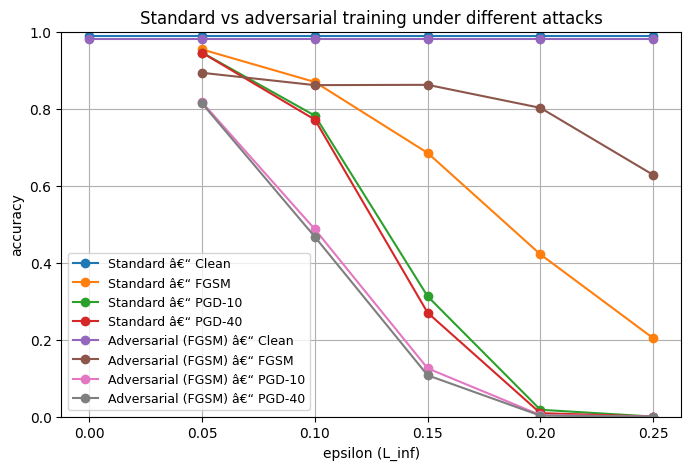

In [24]:
# Run the same sweep for both models and compare side-by-side

df_std = sweep_attacks(model, test_loader, eps_list, pgd_steps_list=(10, 40), max_batches=None)
df_std["training"] = "Standard"

df_adv = sweep_attacks(adv_model, test_loader, eps_list, pgd_steps_list=(10, 40), max_batches=None)
df_adv["training"] = "Adversarial (FGSM)"

df_all = pd.concat([df_std, df_adv], ignore_index=True)

# Table: rows = (training, epsilon), cols = attack, values = accuracy
table2 = df_all.pivot_table(index=["training", "epsilon"], columns="attack", values="accuracy")
display(table2.style.format("{:.3f}"))

# Plot: one curve per (training, attack)
plt.figure(figsize=(8,5))
for training in df_all["training"].unique():
    sub = df_all[df_all["training"] == training]
    for attack in sub["attack"].unique():
        sub2 = sub[sub["attack"] == attack].sort_values("epsilon")
        plt.plot(sub2["epsilon"], sub2["accuracy"], marker="o", label=f"{training} â€“ {attack}")

plt.xlabel("epsilon (L_inf)")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.grid(True)
plt.legend(fontsize=9)
plt.title("Standard vs adversarial training under different attacks")
plt.show()


# Part III: Scaling the Model

This section repeats the full MNIST experimental pipeline with a **clearly larger CNN** so we can study how the robustness-calibration relationship changes with model capacity.

We keep the dataset, attacks, and evaluation metrics fixed and only increase the network size. That way, differences are easier to attribute to capacity rather than to changes in data or preprocessing.


## Part III.A: Larger CNN Standard Training

We first train a larger-capacity MNIST model on clean data using the same cross-entropy objective as the small baseline.


In [25]:
class LargeCNN(nn.Module):
    def __init__(self):
        """
        High-level overview:
        Build a bigger CNN for MNIST than the small baseline.
        """
        super().__init__()
        # More channels and one extra conv layer make this model larger.
        self.conv1 = nn.Conv2d(1, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.fc1 = nn.Linear(256 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        """
        High-level overview:
        Run the image through the larger network and return class scores.
        """
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)   # 28 -> 14
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)   # 14 -> 7
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)   # 7 -> 3
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

large_model = LargeCNN().to(device)
large_optimizer = torch.optim.Adam(large_model.parameters(), lr=1e-3)

# Use the same number of epochs as before.
large_standard_epochs = standard_epochs
for epoch in range(large_standard_epochs):
    loss = train_one_epoch(large_model, train_loader, large_optimizer)
    acc = eval_accuracy(large_model, test_loader)
    print(f"[large-standard] epoch={epoch+1} loss={loss:.4f} test_acc={acc*100:.2f}%")


[large-standard] epoch=1 loss=0.1868 test_acc=98.25%
[large-standard] epoch=2 loss=0.0443 test_acc=99.18%
[large-standard] epoch=3 loss=0.0306 test_acc=99.27%


## Part III.B: Larger CNN Robustness Evaluation

We evaluate the larger clean-trained model under the same FGSM and PGD attacks used for the small CNN so the capacity comparison stays fair.


attack,Clean,FGSM,PGD-10,PGD-40
epsilon,,,,
0.000000,0.993,nan,nan,nan
0.050000,0.993,0.971,0.966,0.966
0.100000,0.993,0.903,0.853,0.848
0.150000,0.993,0.751,0.546,0.520
0.200000,0.993,0.525,0.131,0.090
0.250000,0.993,0.289,0.004,0.001


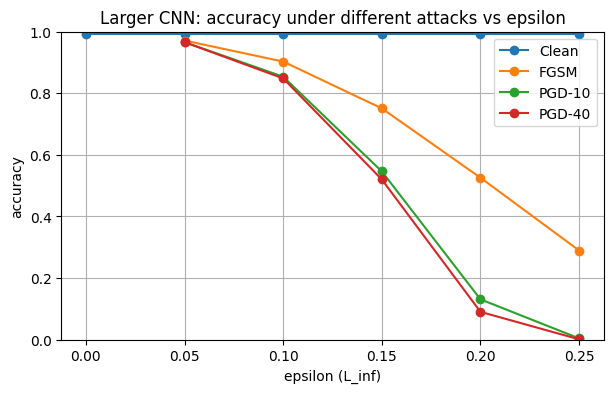

In [26]:
# Use the same epsilon sweep as before so results are easy to compare.
df_large_std = sweep_attacks(large_model, test_loader, eps_list, pgd_steps_list=(10, 40), max_batches=None)
df_large_std["training"] = "Large CNN (Standard)"

table_large_std = df_large_std.pivot_table(index="epsilon", columns="attack", values="accuracy")
display(table_large_std.style.format("{:.3f}"))

plt.figure(figsize=(7, 4))
for col in table_large_std.columns:
    plt.plot(table_large_std.index, table_large_std[col], marker="o", label=col)
plt.xlabel("epsilon (L_inf)")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.grid(True)
plt.legend()
plt.title("Larger CNN: accuracy under different attacks vs epsilon")
plt.show()


## Part III.C: Larger CNN Calibration Evaluation

Next we measure whether scaling the model changes calibration on clean, FGSM, and PGD inputs.


Larger CNN evaluation (MNIST)


,setting,accuracy,nll,ece
0,Clean,0.9927,0.0227,0.0017
1,FGSM (eps=0.15),0.7506,0.8034,0.1305
2,"PGD (eps=0.15, steps=20)",0.5434,1.6123,0.3074


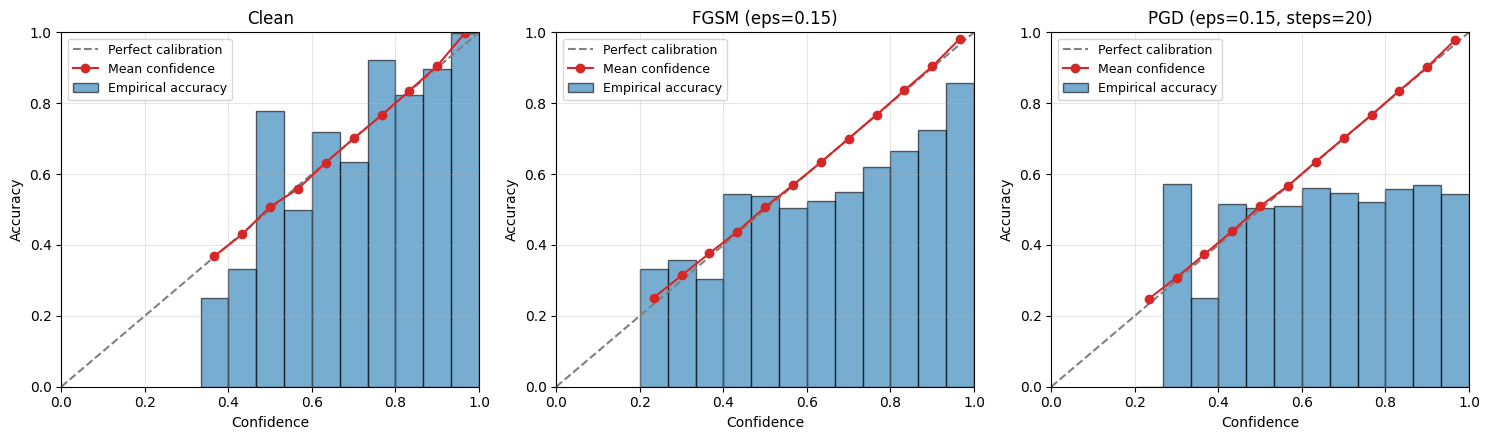

In [27]:
large_summary_df, large_metric_cache = summarize_standard_model(
    large_model,
    test_loader,
    fgsm_eps=standard_eval_eps,
    pgd_eps=standard_eval_eps,
    pgd_alpha=standard_eval_pgd_alpha,
    pgd_steps=standard_eval_pgd_steps,
    n_bins=15,
)

print("Larger CNN evaluation (MNIST)")
display(large_summary_df.style.format({
    "accuracy": "{:.4f}",
    "nll": "{:.4f}",
    "ece": "{:.4f}",
}))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, item in zip(axes, large_metric_cache):
    reliability_diagram_from_logits(
        item["logits"],
        item["labels"],
        n_bins=15,
        ax=ax,
        title=item["setting"],
    )
plt.tight_layout()
plt.show()


## Part III.D: Larger CNN FGSM Adversarial Training

To complete the same pipeline, we adversarially train the larger CNN with FGSM and then evaluate its clean and robust performance.


In [28]:
large_adv_model = LargeCNN().to(device)
large_adv_opt = torch.optim.Adam(large_adv_model.parameters(), lr=1e-3)

# Reuse the same adversarial-training settings.
large_adv_eps = adv_eps
large_adv_lam = lam
large_adv_epochs = epochs

for epoch in range(large_adv_epochs):
    loss = train_one_epoch_adv_fgsm(large_adv_model, train_loader, large_adv_opt, eps=large_adv_eps, lam=large_adv_lam)
    clean_acc = eval_clean(large_adv_model, test_loader)
    print(f"[large-adv-train] epoch={epoch+1} loss={loss:.4f} clean_test_acc={clean_acc*100:.2f}%")


[large-adv-train] epoch=1 loss=0.3638 clean_test_acc=98.20%
[large-adv-train] epoch=2 loss=0.0767 clean_test_acc=98.73%
[large-adv-train] epoch=3 loss=0.0270 clean_test_acc=98.92%


## Part III.E: Capacity Comparison Summary

Finally, we compare small-vs-large capacity and standard-vs-adversarial training under the same attack suite to study how the robustness-calibration tradeoff evolves with model size.


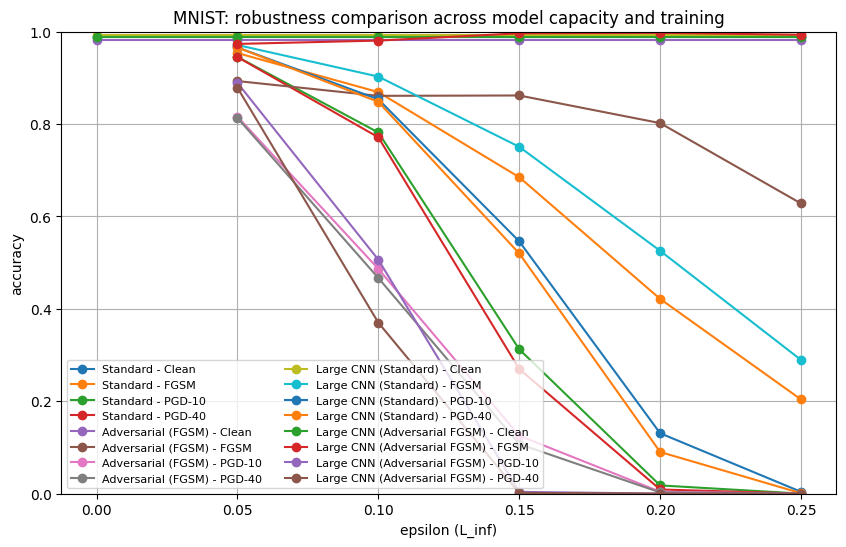

,model,setting,accuracy,nll,ece
0,Small CNN (Standard),Clean,0.9884,0.0348,0.0023
1,Small CNN (Standard),FGSM (eps=0.15),0.6848,0.9958,0.1550
2,Small CNN (Standard),"PGD (eps=0.15, steps=20)",0.2977,2.6129,0.5432
3,Large CNN (Standard),Clean,0.9927,0.0227,0.0017
4,Large CNN (Standard),FGSM (eps=0.15),0.7506,0.8034,0.1305
5,Large CNN (Standard),"PGD (eps=0.15, steps=20)",0.5434,1.6123,0.3074


In [29]:
df_large_adv = sweep_attacks(large_adv_model, test_loader, eps_list, pgd_steps_list=(10, 40), max_batches=None)
df_large_adv["training"] = "Large CNN (Adversarial FGSM)"

mnist_capacity_compare = pd.concat([df_std, df_adv, df_large_std, df_large_adv], ignore_index=True)

capacity_table = mnist_capacity_compare.pivot_table(index=["training", "epsilon"], columns="attack", values="accuracy")
display(capacity_table.style.format("{:.3f}"))

plt.figure(figsize=(10, 6))
for training in mnist_capacity_compare["training"].unique():
    sub = mnist_capacity_compare[mnist_capacity_compare["training"] == training]
    for attack in sub["attack"].unique():
        sub2 = sub[sub["attack"] == attack].sort_values("epsilon")
        plt.plot(sub2["epsilon"], sub2["accuracy"], marker="o", label=f"{training} - {attack}")
plt.xlabel("epsilon (L_inf)")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.grid(True)
plt.legend(fontsize=8, ncol=2)
plt.title("MNIST: robustness comparison across model capacity and training")
plt.show()

small_calibration_summary = standard_summary_df.copy()
small_calibration_summary["model"] = "Small CNN (Standard)"
large_calibration_summary = large_summary_df.copy()
large_calibration_summary["model"] = "Large CNN (Standard)"

calibration_capacity_table = pd.concat([small_calibration_summary, large_calibration_summary], ignore_index=True)
display(calibration_capacity_table[["model", "setting", "accuracy", "nll", "ece"]].style.format({
    "accuracy": "{:.4f}",
    "nll": "{:.4f}",
    "ece": "{:.4f}",
}))


# Part IV: CIFAR-10 Extension

This section repeats the workflow on CIFAR-10 so the same robustness ideas can be tested on a more challenging dataset.


# CIFAR-10: repeat the same experiments

So far we used MNIST (grayscale, $28\times 28$). Now we repeat the same workflow on **CIFAR-10** (RGB, $32\times 32$):

1) Train a standard CNN on clean CIFAR-10  
2) Evaluate robustness vs $\varepsilon$ for FGSM and PGD  
3) Train an adversarially trained CNN (FGSM adversarial training)  
4) Compare robustness curves: standard vs adversarial training

Notes:
- We keep inputs in the pixel range $[0,1]$ (no dataset normalization) so the clipping/projection steps are the same as in MNIST.
- CIFAR-10 is harder than MNIST, so accuracy will be lower for a small CNN trained for only a few epochs.


In [30]:
from torch.utils.data import DataLoader

# CIFAR-10 in [0,1]
cifar_transform = transforms.Compose([transforms.ToTensor()])

cifar_train_ds = datasets.CIFAR10(root="./data", train=True, download=True, transform=cifar_transform)
cifar_test_ds  = datasets.CIFAR10(root="./data", train=False, download=True, transform=cifar_transform)

# DataLoader stability: use num_workers=0 (safe on macOS / Python 3.12)
cifar_train_loader = DataLoader(cifar_train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
cifar_test_loader  = DataLoader(cifar_test_ds,  batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

cifar_classes = cifar_train_ds.classes
cifar_classes

100.0%
c:\Users\Andrew\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [31]:
class SmallCIFARCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.fc1   = nn.Linear(256 * 2 * 2, 256)
        self.fc2   = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)   # 32 -> 16
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)   # 16 -> 8
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)   # 8 -> 4
        x = F.relu(self.conv4(x))
        x = F.max_pool2d(x, 2)   # 4 -> 2
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

cifar_model = SmallCIFARCNN().to(device)
cifar_opt = torch.optim.Adam(cifar_model.parameters(), lr=1e-3)

In [32]:
# Train a few epochs (increase epochs for better accuracy)
cifar_epochs = 5
for epoch in range(cifar_epochs):
    loss = train_one_epoch(cifar_model, cifar_train_loader, cifar_opt)
    acc = eval_clean(cifar_model, cifar_test_loader)
    print(f"[CIFAR-10 clean] epoch={epoch+1} loss={loss:.4f} test_acc={acc*100:.2f}%")

[CIFAR-10 clean] epoch=1 loss=1.6314 test_acc=52.46%
[CIFAR-10 clean] epoch=2 loss=1.1991 test_acc=58.13%
[CIFAR-10 clean] epoch=3 loss=0.9736 test_acc=66.90%
[CIFAR-10 clean] epoch=4 loss=0.8178 test_acc=71.03%
[CIFAR-10 clean] epoch=5 loss=0.6895 test_acc=73.45%


## CIFAR-10 robustness: accuracy vs $\varepsilon$ (different attacks)

We evaluate the clean-trained CIFAR-10 model under the same attacks:

- Clean (no attack)
- FGSM
- PGD-10
- PGD-40


attack,Clean,FGSM,PGD-10,PGD-40
epsilon,,,,
0.000000,0.735,nan,nan,nan
0.001961,0.735,0.649,0.645,0.644
0.003922,0.735,0.567,0.553,0.551
0.007843,0.735,0.420,0.373,0.362
0.015686,0.735,0.217,0.131,0.115
0.031373,0.735,0.067,0.010,0.006


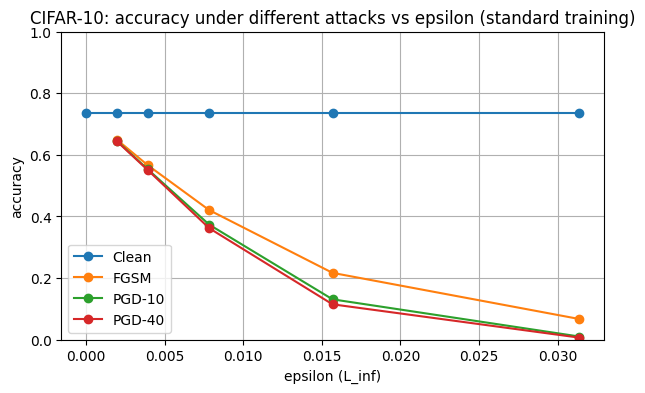

In [33]:
# Sweep attacks for the CIFAR-10 clean-trained model
cifar_eps_list = [0.0, 0.5/255, 1/255, 2/255, 4/255, 8/255]  # common CIFAR scales
df_cifar_std = sweep_attacks(cifar_model, cifar_test_loader, cifar_eps_list, pgd_steps_list=(10, 40), max_batches=None)
df_cifar_std["training"] = "Standard"

table_cifar_std = df_cifar_std.pivot_table(index="epsilon", columns="attack", values="accuracy")
display(table_cifar_std.style.format("{:.3f}"))

plt.figure(figsize=(7,4))
for col in table_cifar_std.columns:
    plt.plot(table_cifar_std.index, table_cifar_std[col], marker="o", label=col)
plt.xlabel("epsilon (L_inf)")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.grid(True)
plt.legend()
plt.title("CIFAR-10: accuracy under different attacks vs epsilon (standard training)")
plt.show()


## CIFAR-10 adversarial training (FGSM)

We adversarially train a second CIFAR-10 model using FGSM examples with a fixed budget $\varepsilon$.

We then compare robustness curves: standard vs adversarial training.

In [34]:
cifar_adv_model = SmallCIFARCNN().to(device)
cifar_adv_opt = torch.optim.Adam(cifar_adv_model.parameters(), lr=1e-3)

cifar_adv_eps = 8/255   # typical training budget on CIFAR-10
cifar_lam = 0.5
cifar_adv_epochs = 5

for epoch in range(cifar_adv_epochs):
    loss = train_one_epoch_adv_fgsm(cifar_adv_model, cifar_train_loader, cifar_adv_opt, eps=cifar_adv_eps, lam=cifar_lam)
    acc = eval_clean(cifar_adv_model, cifar_test_loader)
    print(f"[CIFAR-10 adv-train] epoch={epoch+1} loss={loss:.4f} clean_test_acc={acc*100:.2f}%")

[CIFAR-10 adv-train] epoch=1 loss=1.9380 clean_test_acc=45.85%
[CIFAR-10 adv-train] epoch=2 loss=1.6587 clean_test_acc=54.45%
[CIFAR-10 adv-train] epoch=3 loss=1.5406 clean_test_acc=58.16%
[CIFAR-10 adv-train] epoch=4 loss=1.4669 clean_test_acc=62.14%
[CIFAR-10 adv-train] epoch=5 loss=1.3953 clean_test_acc=57.53%


## CIFAR-10: standard vs adversarial training (side-by-side)

Same evaluation as before, but now comparing both CIFAR-10 models.

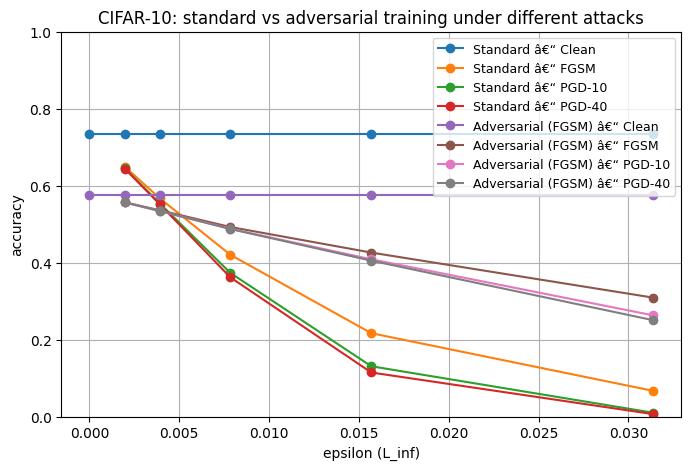

In [35]:
df_cifar_adv = sweep_attacks(cifar_adv_model, cifar_test_loader, cifar_eps_list, pgd_steps_list=(10, 40), max_batches=None)
df_cifar_adv["training"] = "Adversarial (FGSM)"

df_cifar_all = pd.concat([df_cifar_std, df_cifar_adv], ignore_index=True)

table_cifar = df_cifar_all.pivot_table(index=["training", "epsilon"], columns="attack", values="accuracy")
display(table_cifar.style.format("{:.3f}"))

plt.figure(figsize=(8,5))
for training in df_cifar_all["training"].unique():
    sub = df_cifar_all[df_cifar_all["training"] == training]
    for attack in sub["attack"].unique():
        sub2 = sub[sub["attack"] == attack].sort_values("epsilon")
        plt.plot(sub2["epsilon"], sub2["accuracy"], marker="o", label=f"{training} â€“ {attack}")

plt.xlabel("epsilon (L_inf)")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.grid(True)
plt.legend(fontsize=9)
plt.title("CIFAR-10: standard vs adversarial training under different attacks")
plt.show()